Loading datasets...
Training Set Shape: (147613, 51)
Testing Set Shape:  (63267, 51)

Preprocessing and encoding categorical features...
Features after encoding: 64

Treinando classificador binário (XGBoost)
Fazendo fit no modelo...
Predizendo no conjunto de teste...

--- Relatório - Classe Binária ---
              precision    recall  f1-score   support

  Normal (0)       0.74      0.89      0.81     30351
  Ataque (1)       0.87      0.71      0.78     32916

    accuracy                           0.80     63267
   macro avg       0.81      0.80      0.80     63267
weighted avg       0.81      0.80      0.80     63267



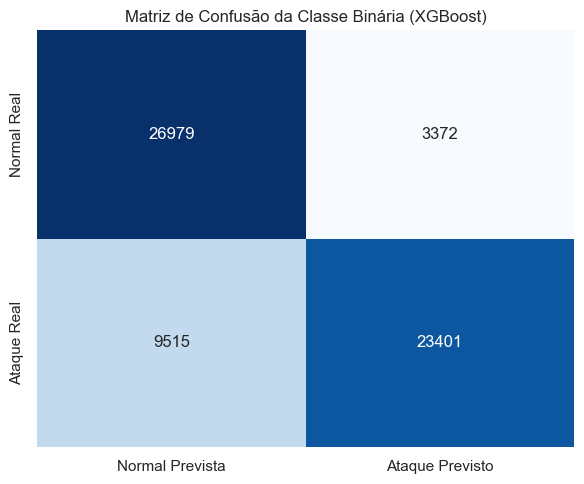


Treinando o Classificador Multi-Classe (XGBoost)
Fazendo fit no modelo...
Predizendo no conjunto de teste...

--- Relatório - Multiclasse ---
                precision    recall  f1-score   support

      Analysis       0.30      0.46      0.36      3990
           DoS       1.00      1.00      1.00     11847
      Exploits       0.36      0.62      0.45      8192
       Fuzzers       0.29      0.65      0.40      4085
        Normal       0.84      0.46      0.60     30351
Reconnaissance       0.79      0.87      0.83      4802

      accuracy                           0.63     63267
     macro avg       0.60      0.68      0.61     63267
  weighted avg       0.73      0.63      0.64     63267



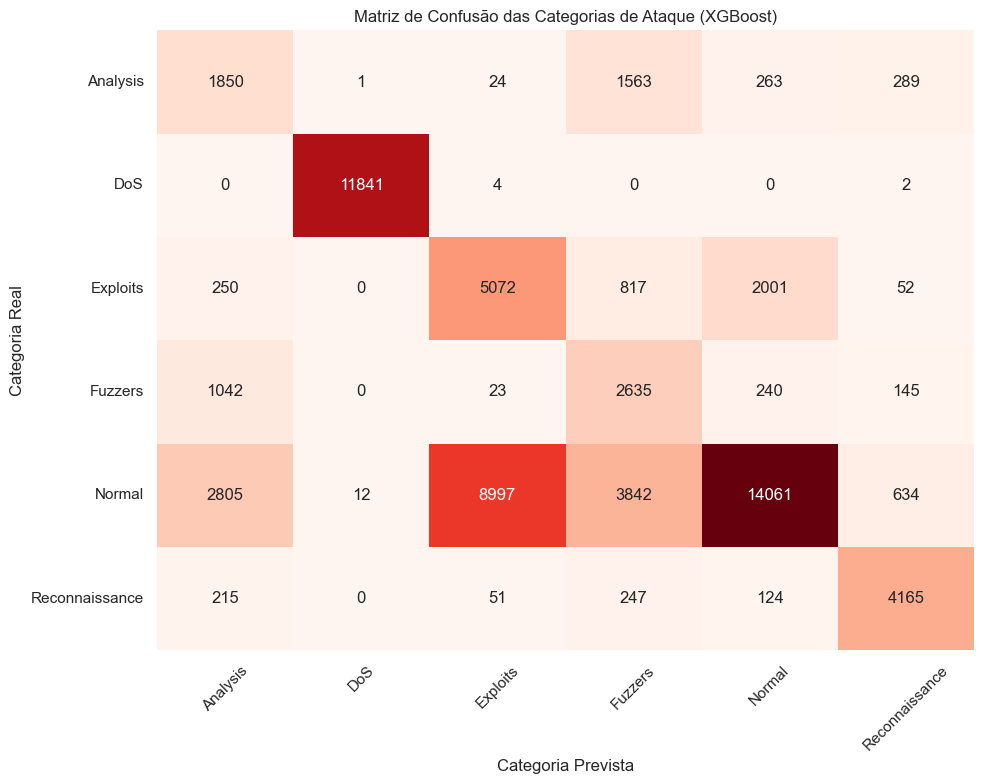


Top 10 Features Mais Importantes (XGBoost)
         Feature  Importancia
ct_dst_sport_ltm     0.210118
       state_CON     0.111301
ct_flw_http_mthd     0.108701
       service_-     0.077585
     trans_depth     0.067435
           spkts     0.063324
      ct_srv_dst     0.057399
      ct_srv_src     0.035445
          synack     0.029353
ct_src_dport_ltm     0.022153


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix

# Set visualization style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. LOAD DATASETS
# ==========================================
print("Loading datasets...")
train_df = pd.read_csv("ubuntu-server_training-set.csv")
test_df = pd.read_csv("ubuntu-server_testing-set.csv")

print(f"Training Set Shape: {train_df.shape}")
print(f"Testing Set Shape:  {test_df.shape}")

# ==========================================
# 2. DATA PREPROCESSING & ENCODING
# ==========================================
print("\nPreprocessing and encoding categorical features...")

# Define targets and the specific network identity/time columns that ML cannot process
targets = ['label', 'attack_cat']
identities = ['id', 'srcip', 'sport', 'dstip', 'dsport', 'stime', 'ltime', 'ct_state_ttl']

# Combine them into a single list of columns to drop safely
drop_cols = targets + identities

# Separate features (X) and targets (y)
X_train = train_df.drop(columns=[col for col in drop_cols if col in train_df.columns])
y_train_bin = train_df['label']
y_train_multi = train_df['attack_cat']

X_test = test_df.drop(columns=[col for col in drop_cols if col in test_df.columns])
y_test_bin = test_df['label']
y_test_multi = test_df['attack_cat']

# Categorical columns to encode (Features)
cat_cols = ['proto', 'service', 'state']

# Apply One-Hot Encoding to categorical features
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols)

# Align Train and Test columns 
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# NOVO PARA XGBOOST: O target multiclasse não pode ser string. 
# Precisamos converter "Normal", "DoS", etc. para 0, 1, 2...
label_encoder = LabelEncoder()
y_train_multi_encoded = label_encoder.fit_transform(y_train_multi)
# Atenção: Usamos apenas transform() no teste para manter o mapeamento exato do treino
y_test_multi_encoded = label_encoder.transform(y_test_multi)

# Guardar os nomes das classes para os gráficos e relatórios
class_names = label_encoder.classes_

print(f"Features after encoding: {X_train_encoded.shape[1]}")

# ==========================================
# 3. BINARY CLASSIFICATION (Attack vs Normal)
# ==========================================
print("\n" + "="*50)
print("Treinando classificador binário (XGBoost)")
print("="*50)

# Calcular pesos das amostras para lidar com o desbalanceamento
sample_weights_bin = compute_sample_weight(class_weight='balanced', y=y_train_bin)

# Initialize XGBoost for Binary Classification
xgb_bin = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1
)

print("Fazendo fit no modelo...")
xgb_bin.fit(X_train_encoded, y_train_bin, sample_weight=sample_weights_bin)

print("Predizendo no conjunto de teste...")
y_pred_bin = xgb_bin.predict(X_test_encoded)

# Binary Metrics
print("\n--- Relatório - Classe Binária ---")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Normal (0)', 'Ataque (1)']))

# Binary Confusion Matrix
plt.figure(figsize=(6, 5))
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal Prevista', 'Ataque Previsto'],
            yticklabels=['Normal Real', 'Ataque Real'])
plt.title('Matriz de Confusão da Classe Binária (XGBoost)')
plt.tight_layout()
plt.show()

# ==========================================
# 4. MULTI-CLASS CLASSIFICATION (Attack Categories)
# ==========================================
print("\n" + "="*50)
print("Treinando o Classificador Multi-Classe (XGBoost)")
print("="*50)

# Calcular pesos das amostras multiclasse
sample_weights_multi = compute_sample_weight(class_weight='balanced', y=y_train_multi_encoded)

# Initialize XGBoost for Multi-Class Classification
xgb_multi = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softmax',
    num_class=len(class_names),
    random_state=42,
    n_jobs=-1
)

print("Fazendo fit no modelo...")
xgb_multi.fit(X_train_encoded, y_train_multi_encoded, sample_weight=sample_weights_multi)

print("Predizendo no conjunto de teste...")
y_pred_multi_encoded = xgb_multi.predict(X_test_encoded)

# Reverter os números (0, 1, 2) de volta para strings ("Normal", "DoS") para o relatório
y_pred_multi = label_encoder.inverse_transform(y_pred_multi_encoded)

# Multi-Class Metrics
print("\n--- Relatório - Multiclasse ---")
print(classification_report(y_test_multi, y_pred_multi, target_names=class_names))

# Multi-Class Confusion Matrix
plt.figure(figsize=(10, 8))
# Passamos os arrays originais (com strings) para que a matriz gere os labels corretamente
cm_multi = confusion_matrix(y_test_multi, y_pred_multi, labels=class_names)

sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão das Categorias de Ataque (XGBoost)')
plt.xlabel('Categoria Prevista')
plt.ylabel('Categoria Real')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# 5. FEATURE IMPORTANCE
# ==========================================
print("\n" + "="*50)
print("Top 10 Features Mais Importantes (XGBoost)")
print("="*50)

feature_importances = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Importancia': xgb_multi.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print(feature_importances.head(10).to_string(index=False))